In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Setup

In [17]:
df = pd.read_csv("C:/Users/Pc/Downloads/population_by_country_2020.csv", encoding= "latin1")
print(df)

    Country (or dependency)  Population (2020) Yearly Change  Net Change  \
0                     China         1440297825        0.39 %     5540090   
1                     India         1382345085        0.99 %    13586631   
2             United States          331341050        0.59 %     1937734   
3                 Indonesia          274021604        1.07 %     2898047   
4                  Pakistan          221612785        2.00 %     4327022   
..                      ...                ...           ...         ...   
230              Montserrat               4993        0.06 %           3   
231        Falkland Islands               3497        3.05 %         103   
232                    Niue               1628        0.68 %          11   
233                 Tokelau               1360        1.27 %          17   
234                Holy See                801        0.25 %           2   

     Density (P/KmÂ²)  Land Area (KmÂ²)  Migrants (net) Fert. Rate Med. Age  \
0       

In [6]:
df.head(20)

,Country (or dependency),Population (2020),Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share
0,China,1440297825,0.39 %,5540090,153,9388211,-348399.0,1.7,38,61 %,18.47 %
1,India,1382345085,0.99 %,13586631,464,2973190,-532687.0,2.2,28,35 %,17.70 %
2,United States,331341050,0.59 %,1937734,36,9147420,954806.0,1.8,38,83 %,4.25 %
3,Indonesia,274021604,1.07 %,2898047,151,1811570,-98955.0,2.3,30,56 %,3.51 %
4,Pakistan,221612785,2.00 %,4327022,287,770880,-233379.0,3.6,23,35 %,2.83 %
5,Brazil,212821986,0.72 %,1509890,25,8358140,21200.0,1.7,33,88 %,2.73 %
6,Nigeria,206984347,2.58 %,5175990,226,910770,-60000.0,5.4,18,52 %,2.64 %
7,Bangladesh,164972348,1.01 %,1643222,1265,130170,-369501.0,2.1,28,39 %,2.11 %
8,Russia,145945524,0.04 %,62206,9,16376870,182456.0,1.8,40,74 %,1.87 %
9,Mexico,129166028,1.06 %,1357224,66,1943950,-60000.0,2.1,29,84 %,1.65 %


In [7]:
percentage_column = ["Yearly Change", "Urban Pop %", "World Share"]
for col in percentage_column:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace("%","", regex=False),
                            errors="coerce"
                           )


# Convert Med. Age to numeric
df["Med. Age"] = pd.to_numeric(df["Med. Age"], errors="coerce")

#Handling the missing value 
df["Med. Age"] = df["Med. Age"].fillna(df["Med. Age"].median())
df["Migrants (net)"] = df["Migrants (net)"].fillna(df["Migrants (net)"].median())

In [8]:
print(df[["Med. Age", "Migrants (net)"]].isnull().sum())

Med. Age          0
Migrants (net)    0
dtype: int64


In [9]:
print(df.dtypes)

Country (or dependency)     object
Population (2020)            int64
Yearly Change              float64
Net Change                   int64
Density (P/KmÂ²)             int64
Land Area (KmÂ²)             int64
Migrants (net)             float64
Fert. Rate                  object
Med. Age                   float64
Urban Pop %                float64
World Share                float64
dtype: object


# NUMPY

In [11]:
# Convert the 'Population (2020)' column to a NumPy array and compute the mean, median, standard 
#deviation, and total world population. 
population = df["Population (2020)"].to_numpy()
print("Mean", np.mean(population))
print("Median", np.median(population))
print("Standard Deviation", np.std(population))
print("Total World Population", np.sum(population))


Mean 33227444.280851062
Median 5460109.0
Standard Deviation 135015251.93245462
Total World Population 7808449406


In [12]:
print(df.columns.tolist())

['Country (or dependency)', 'Population (2020)', 'Yearly Change', 'Net Change', 'Density (P/KmÂ²)', 'Land Area (KmÂ²)', 'Migrants (net)', 'Fert. Rate', 'Med. Age', 'Urban Pop %', 'World Share']


In [13]:
#Use np.percentile to find the 25th, 50th, and 75th percentiles of 'Density (P/Km²)'
density = df["Density (P/KmÂ²)"].to_numpy()
print("25th Percentile", np.percentile(density, 25))
print("50th Percentile", np.percentile(density, 50))
print("75th Percentile", np.percentile(density, 75))

25th Percentile 37.0
50th Percentile 95.0
75th Percentile 239.5


In [14]:
#Use np.where to create a new array labeling each country as "High Density" if density > 500, else 
#"Low Density".
density_label = np.where(df["Density (P/KmÂ²)"] > 500, "High Density", "Low Density")
print(density_label)

['Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'High Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'High Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'High Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'Low Density' 'Low Density'
 'Low Density' 'Low Density' 'Low Density' 'High Density' 'Low Density'
 '

In [16]:
#Use np.log to create a log-transformed population array (population values vary by orders of 
#magnitude — log helps visualize this). 
population_log = np.log(df["Population (2020)"])
print(population_log)

0      21.088116
1      21.047047
2      19.618659
3      19.428718
4      19.216442
         ...    
230     8.515792
231     8.159661
232     7.395108
233     7.215240
234     6.685861
Name: Population (2020), Length: 235, dtype: float64


In [17]:
#Compute the correlation coefficient (np.corrcoef) between 'Fert. Rate' and 'Med. Age'.

#Pehle dono columns ko numeric banao
df["Fert. Rate"] = pd.to_numeric(df["Fert. Rate"], errors="coerce")
df["Med. Age"] = pd.to_numeric(df["Med. Age"], errors="coerce")


#Missing values fill karo
df["Fert. Rate"] = df["Fert. Rate"].fillna(df["Fert. Rate"].median())
df["Med. Age"] = df["Med. Age"].fillna(df["Med. Age"].median())


#correlation
fertility = df["Fert. Rate"].to_numpy()
med_age = df["Med. Age"].to_numpy()

correlation = np.corrcoef(fertility, med_age)

print(correlation)

[[ 1.         -0.87285931]
 [-0.87285931  1.        ]]


# Pandas

In [18]:
#Find the top 10 most populous countries and the top 10 least populous countries.

top10 = df.sort_values(by="Population (2020)", ascending=False).head(10)
print(top10)

bottom10 = df.sort_values(by="Population (2020)", ascending=True).head(10)
print(bottom10)

  Country (or dependency)  Population (2020)  Yearly Change  Net Change  \
0                   China         1440297825           0.39     5540090   
1                   India         1382345085           0.99    13586631   
2           United States          331341050           0.59     1937734   
3               Indonesia          274021604           1.07     2898047   
4                Pakistan          221612785           2.00     4327022   
5                  Brazil          212821986           0.72     1509890   
6                 Nigeria          206984347           2.58     5175990   
7              Bangladesh          164972348           1.01     1643222   
8                  Russia          145945524           0.04       62206   
9                  Mexico          129166028           1.06     1357224   

   Density (P/KmÂ²)  Land Area (KmÂ²)  Migrants (net)  Fert. Rate  Med. Age  \
0               153           9388211       -348399.0         1.7      38.0   
1               

In [20]:
#Sort by 'World Share' and compute the cumulative sum — how many countries account for 50% of 
#world population? 
df_sorted = df.sort_values(by="World Share", ascending=False)

df_sorted["Cumulative Sum"] = df_sorted["World Share"].cumsum()

result = df_sorted[df_sorted["Cumulative Sum"] <= 50]

print(len(result))

6


In [22]:
#Find countries with negative 'Migrants (net)' (net emigration) vs. positive (net immigration); count each 
#group.
negative = df[df["Migrants (net)"] < 0 ]
positive = df[df["Migrants (net)"] > 0 ]  # double df is used for the boolean indexing in pandas

print("Negative Migration", len(negative))
print("Positive Migration", len(positive))


Negative Migration 147
Positive Migration 83


In [23]:
#Use .corr() to build a correlation matrix across all numeric columns. 
correlation_matrix = df.corr(numeric_only = True)
print(correlation_matrix)

                   Population (2020)  Yearly Change  Net Change  \
Population (2020)           1.000000      -0.009504    0.852329   
Yearly Change              -0.009504       1.000000    0.190087   
Net Change                  0.852329       0.190087    1.000000   
Density (P/KmÂ²)           -0.025433      -0.026965   -0.033803   
Land Area (KmÂ²)            0.455486       0.009098    0.305668   
Migrants (net)             -0.265594      -0.014582   -0.299429   
Fert. Rate                 -0.036400       0.792957    0.178572   
Med. Age                    0.021360      -0.784583   -0.187200   
Urban Pop %                -0.034775      -0.273381   -0.143621   
World Share                 0.999998      -0.009736    0.851809   

                   Density (P/KmÂ²)  Land Area (KmÂ²)  Migrants (net)  \
Population (2020)         -0.025433          0.455486       -0.265594   
Yearly Change             -0.026965          0.009098       -0.014582   
Net Change                -0.033803        

In [25]:
#Create a new column 'Population Density Category' bucketing 'Density (P/Km²)' into Low / Medium / 
#High / Very High using pd.cut. 
df["Population Density Category"] = pd.cut(
    df["Density (P/KmÂ²)"],
    bins= [0, 100, 500, 1000, float("inf")],
    labels = ["low", "medium", "high", "very high"]
)
print(df[["Country (or dependency)", "Density (P/KmÂ²)", "Population Density Category"]])

    Country (or dependency)  Density (P/KmÂ²) Population Density Category
0                     China               153                      medium
1                     India               464                      medium
2             United States                36                         low
3                 Indonesia               151                      medium
4                  Pakistan               287                      medium
..                      ...               ...                         ...
230              Montserrat                50                         low
231        Falkland Islands                 0                         NaN
232                    Niue                 6                         low
233                 Tokelau               136                      medium
234                Holy See              2003                   very high

[235 rows x 3 columns]


In [26]:
#Find the country with the highest 'Fert. Rate' and the one with the highest 'Med. Age' — what pattern do 
you notice?
highest_fert = df.loc[df["Fert. Rate"].idxmax()]
highest_age = df.loc[df["Med. Age"].idxmax()]

print("Highest Fertility Rate")
print(highest_fert[["Country (or dependency)", "Fert. Rate"]])

print("\nHighest Median Age Country")
print(highest_age[["Country (or dependency)", "Med. Age"]])


Object `notice` not found.
Highest Fertility Rate
Country (or dependency)    Niger
Fert. Rate                   7.0
Name: 55, dtype: object

Highest Median Age Country
Country (or dependency)    Japan
Med. Age                    48.0
Name: 10, dtype: object


In [27]:
#Filter countries where 'Urban Pop %' > 90 and sort by 'Population (2020)' descending.
urban = df[df["Urban Pop %"] > 90]

urban = urban.sort_values(by="Population (2020)", ascending=False)

print(urban[["Country (or dependency)", "Urban Pop %", "Population (2020)"]])

     Country (or dependency)  Urban Pop %  Population (2020)
10                     Japan         92.0          126407422
31                 Argentina         93.0           45267449
68               Netherlands         92.0           17141544
80                   Belgium         98.0           11598451
87                    Jordan         91.0           10220604
99                    Israel         93.0            8678517
133                  Uruguay         96.0            3475842
138                    Qatar         96.0            2889284
161                 RÃ©union        100.0             896422
173                    Malta         93.0             441750
178               Martinique         92.0             375213
179                  Iceland         94.0             341628
190                     Guam         95.0             169031
198      U.S. Virgin Islands         96.0             104398
204           Cayman Islands         97.0              65854
205                  Ber

# SEABORN

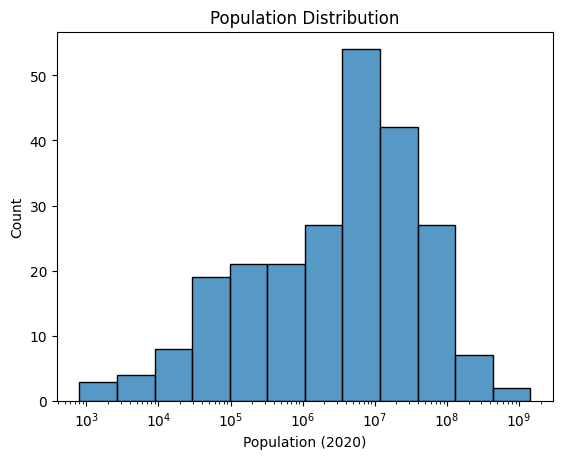

In [28]:
#Create a sns.histplot (with log_scale=True) of 'Population (2020)' to visualize the skewed distribution.

import seaborn as sns
import matplotlib.pyplot as plt 
sns.histplot(data=df, x="Population (2020)", log_scale=True)

plt.title("Population Distribution")
plt.xlabel("Population (2020)")
plt.ylabel("Count")
plt.show()

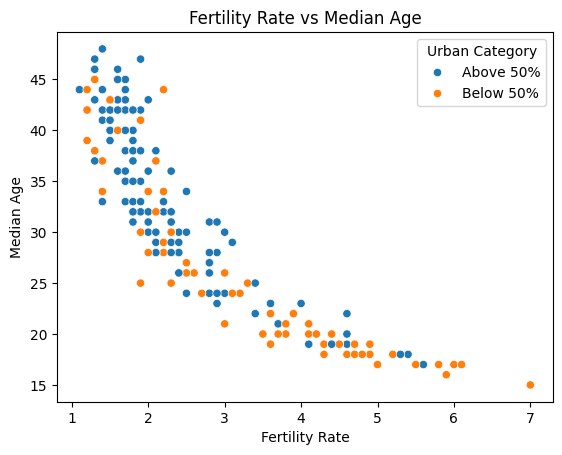

In [30]:
#Create a sns.scatterplot of 'Fert. Rate' vs 'Med. Age', colored by whether 'Urban Pop %' is above or 
#below 50%. 

import seaborn as sns
import matplotlib.pyplot as plt

df["Urban Category"] = df["Urban Pop %"].apply(
    lambda x: "Above 50%" if x > 50 else "Below 50%"
)

sns.scatterplot(
    data=df,
    x="Fert. Rate",
    y="Med. Age",
    hue="Urban Category"
)

plt.title("Fertility Rate vs Median Age")
plt.xlabel("Fertility Rate")
plt.ylabel("Median Age")
plt.show()

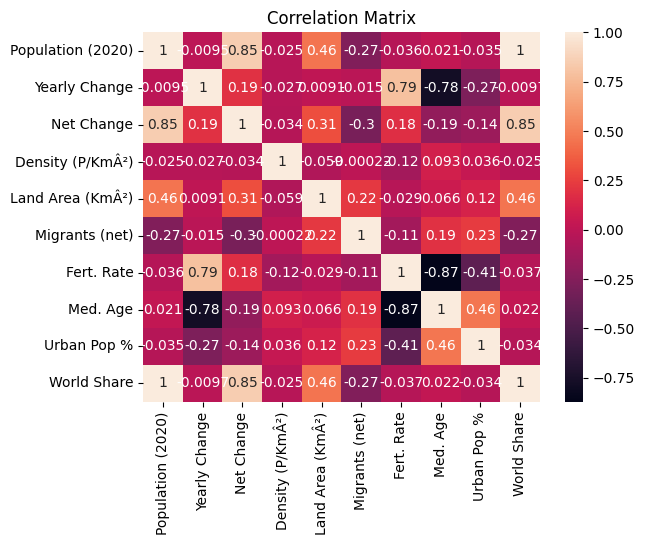

In [31]:
#Create a sns.heatmap of the correlation matrix from the Pandas section. 
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Matrix")
plt.show()

In [33]:
print(df.columns.tolist())

['Country (or dependency)', 'Population (2020)', 'Yearly Change', 'Net Change', 'Density (P/KmÂ²)', 'Land Area (KmÂ²)', 'Migrants (net)', 'Fert. Rate', 'Med. Age', 'Urban Pop %', 'World Share', 'Population Density Category', 'Urban Category']


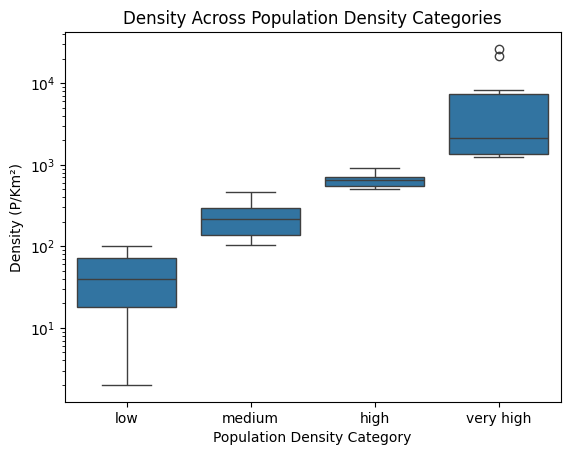

In [35]:
#Create a sns.boxplot comparing 'Density (P/Km²)' across the density categories (use log scale on y
#axis). 
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="Population Density Category",
    y="Density (P/KmÂ²)"
)

plt.yscale("log")

plt.title("Density Across Population Density Categories")
plt.xlabel("Population Density Category")
plt.ylabel("Density (P/Km²)")
plt.show()

In [6]:
print(df[["Urban Pop %", "Fert. Rate"]].dtypes)


Urban Pop %    object
Fert. Rate     object
dtype: object


In [18]:
df["Urban Pop %"] = pd.to_numeric(df["Urban Pop %"], errors="coerce")
df["Fert. Rate"] = pd.to_numeric(df["Fert. Rate"], errors="coerce")

In [19]:
print(df.shape)

print(df[["Urban Pop %", "Fert. Rate"]].dtypes)

print(df[["Urban Pop %", "Fert. Rate"]].head())

print(df[["Urban Pop %", "Fert. Rate"]].isnull().sum())

(235, 11)
Urban Pop %    float64
Fert. Rate     float64
dtype: object
   Urban Pop %  Fert. Rate
0          NaN         1.7
1          NaN         2.2
2          NaN         1.8
3          NaN         2.3
4          NaN         3.6
Urban Pop %    235
Fert. Rate      34
dtype: int64


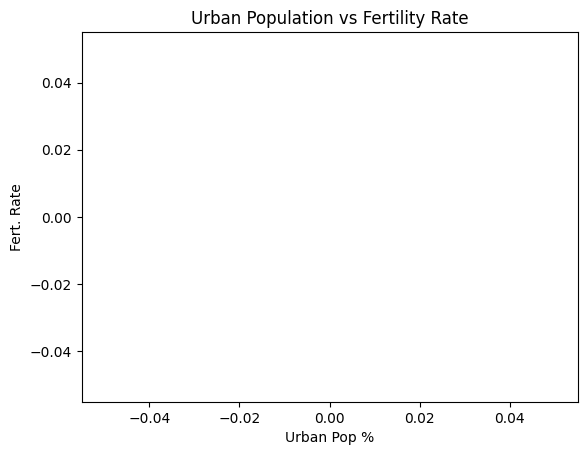

In [21]:
#Create a sns.regplot to check if there's a linear relationship between 'Urban Pop %' and 'Fert. Rate'.
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x="Urban Pop %",
    y="Fert. Rate"
)

plt.title("Urban Population vs Fertility Rate")
plt.xlabel("Urban Pop %")
plt.ylabel("Fert. Rate")
plt.show()

# Matplotlib

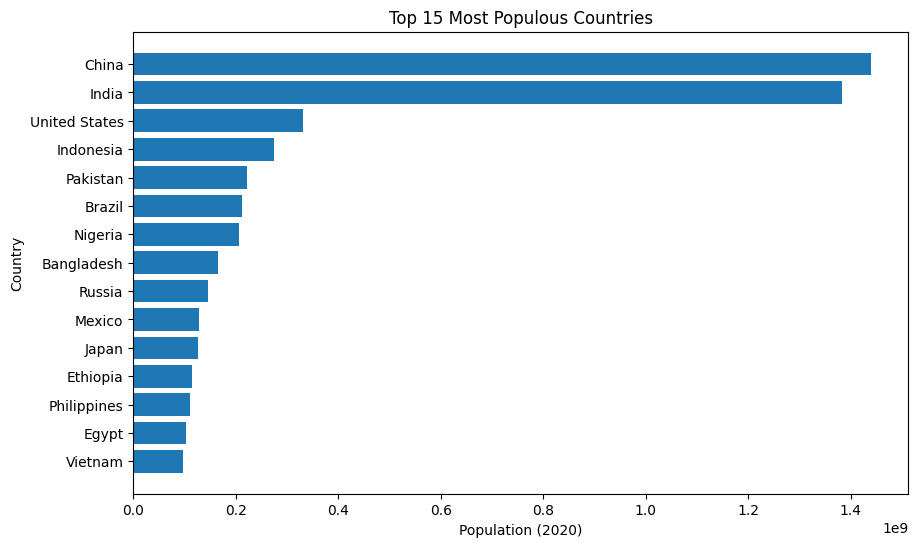

In [23]:
#Create a horizontal bar chart of the top 15 countries by 'Population (2020)'.

import matplotlib.pyplot as plt

top15 = df.nlargest(15, "Population (2020)")

plt.figure(figsize=(10,6))

plt.barh(
    top15["Country (or dependency)"],
    top15["Population (2020)"]
)

plt.title("Top 15 Most Populous Countries")
plt.xlabel("Population (2020)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

In [26]:
print(df["World Share"].dtype)


object


In [27]:
df["World Share"] = pd.to_numeric(
    df["World Share"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)

In [28]:
print(df["World Share"].dtype)


float64


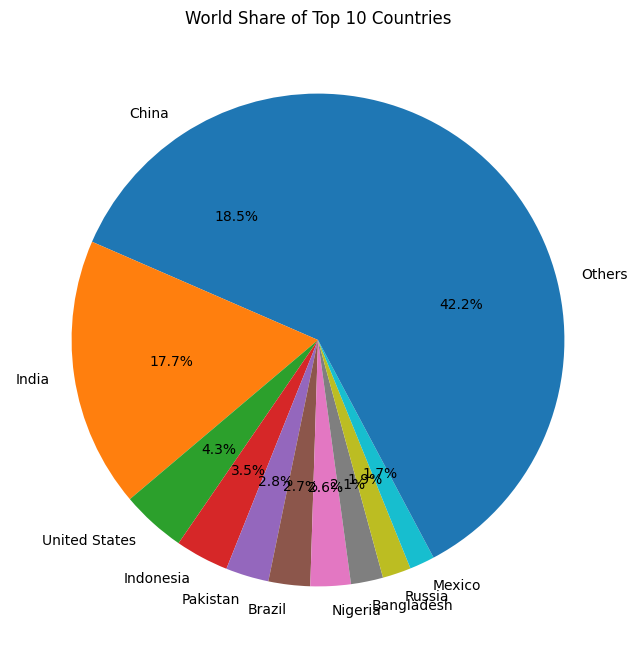

In [29]:
#Create a pie chart showing the 'World Share %' of the top 10 countries plus an "Others" slice. 

import matplotlib.pyplot as plt

top10 = df.nlargest(10, "Population (2020)")

others = df["World Share"].sum() - top10["World Share"].sum()

labels = list(top10["Country (or dependency)"])
labels.append("Others")

sizes = list(top10["World Share"])
sizes.append(others)

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("World Share of Top 10 Countries")

plt.show()

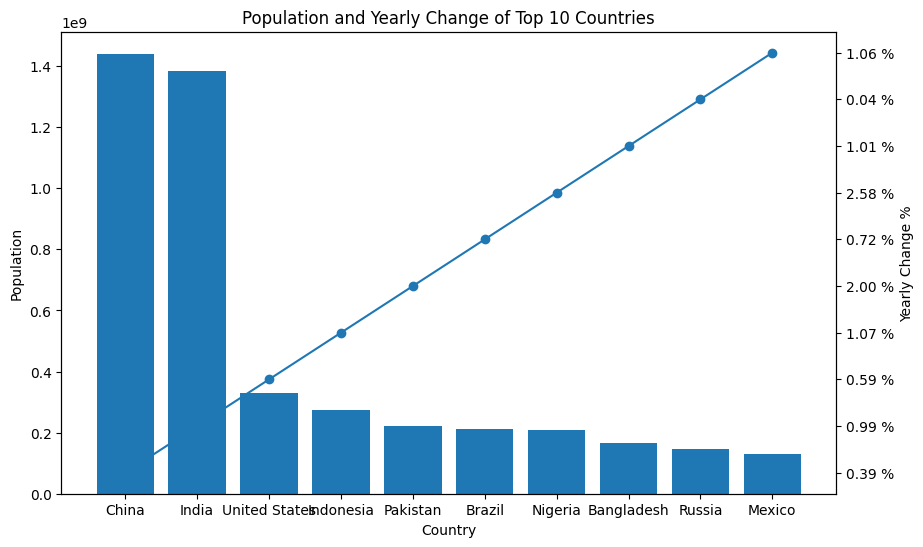

In [30]:
#Create a dual-axis plot showing 'Population (2020)' (bar) and 'Yearly Change %' (line) for the top 10 
#countries.
import matplotlib.pyplot as plt

top10 = df.nlargest(10, "Population (2020)")

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(
    top10["Country (or dependency)"],
    top10["Population (2020)"]
)

ax1.set_xlabel("Country")
ax1.set_ylabel("Population")

ax2 = ax1.twinx()

ax2.plot(
    top10["Country (or dependency)"],
    top10["Yearly Change"],
    marker="o"
)

ax2.set_ylabel("Yearly Change %")

plt.title("Population and Yearly Change of Top 10 Countries")
plt.xticks(rotation=45)

plt.show()

In [31]:
df.rename(columns={
    "Land Area (KmÂ²)": "Land Area (Km²)",
    "Density (P/KmÂ²)": "Density (P/Km²)"
}, inplace=True)

In [32]:
import pandas as pd

df["Land Area (Km²)"] = pd.to_numeric(df["Land Area (Km²)"], errors="coerce")
df["Population (2020)"] = pd.to_numeric(df["Population (2020)"], errors="coerce")
df["Density (P/Km²)"] = pd.to_numeric(df["Density (P/Km²)"], errors="coerce")

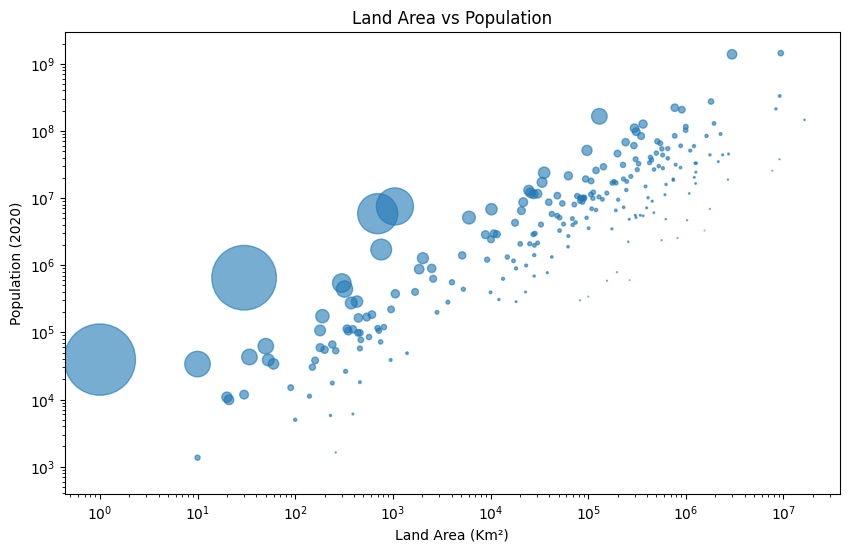

In [33]:
#Create a scatter plot of 'Land Area (Km²)' vs 'Population (2020)' (both log-scaled) with point size 
#mapped to 'Density (P/Km²)'.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["Land Area (Km²)"],
    df["Population (2020)"],
    s=df["Density (P/Km²)"] / 10,
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Land Area vs Population")
plt.xlabel("Land Area (Km²)")
plt.ylabel("Population (2020)")

plt.show()